# Nijmegen Floods - Non-Parametric Bayesian Networks

### Importing necessary packages

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from Functions import *
from py_banshee.rankcorr import bn_rankcorr
from py_banshee.copula_test import cvm_statistic
from py_banshee.sample_bn import generate_samples
from py_banshee.bn_plot import bn_visualize

## Environmental Variables

The following environmental variables are extracted and used for the NPBN analysis:
- $Q$: River discharge of the river Waal
- $T$: Temperature in the alps (Grimsel Hospiz station - Switserland)
- $P$: Precipitation in Düsseldorf
- $GW$: Groundwater levels near Nijmegen (Wijchen)

All data is imported from different data file-types, and resampled to daily mean values.

### River Discharge

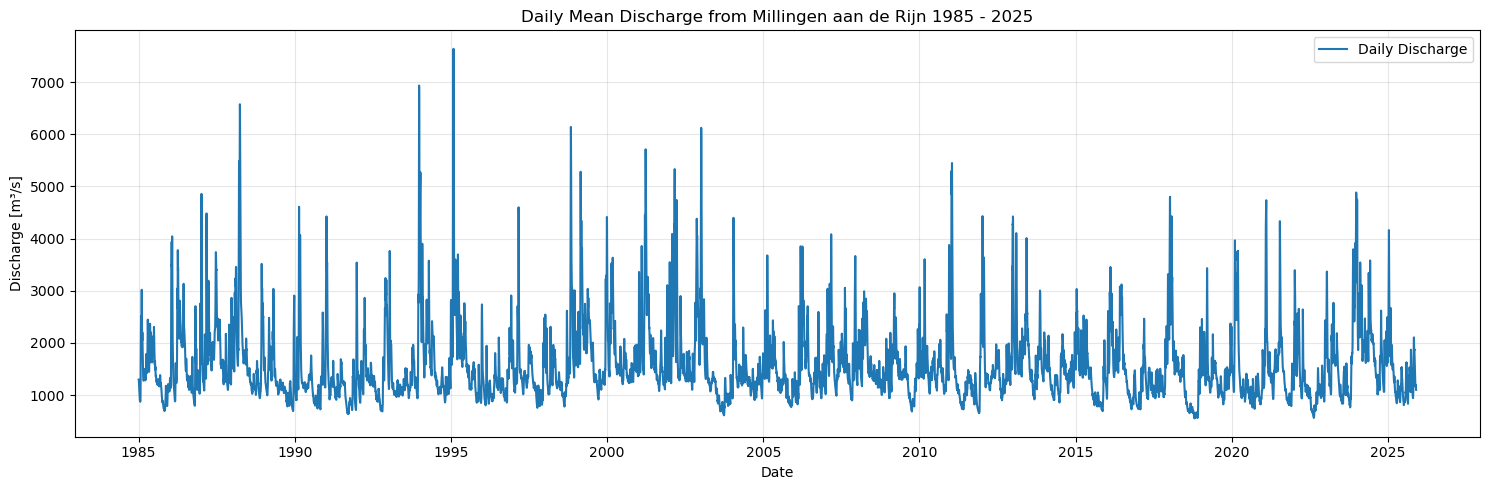

In [2]:
discharge_files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

df_discharge = []

for file_name in discharge_files:
    df = pd.read_csv(file_name, sep=';')

    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)                        # convert to datetime     
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))    # convert to numeric
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan                                   # remove outliers
    df = df.dropna(subset=["datum", "waarde"])                                      # drop rows with NaN

    # Resample to daily mean
    daily_part = df.groupby("datum")["waarde"].mean()
    df_discharge.append(daily_part)

df_discharge = pd.concat(df_discharge).sort_index()


plt.figure(figsize=(15, 5))
plt.plot(df_discharge.index, df_discharge.values, label = "Daily Discharge")
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()


### Temperature Alps

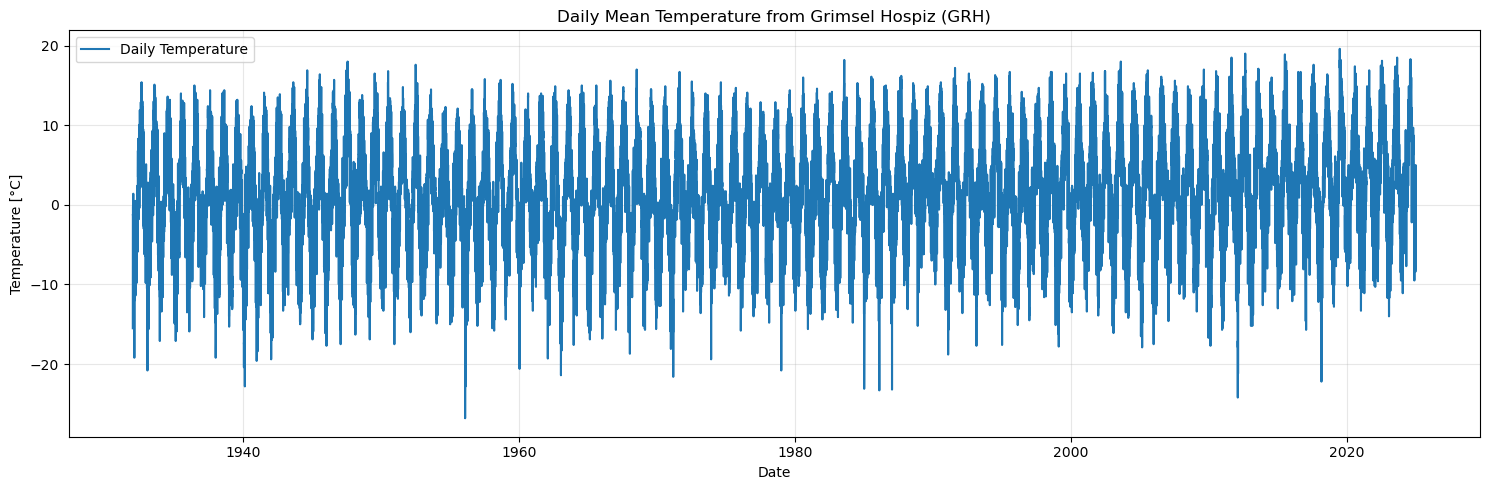

In [3]:
temperature_file = 'data/ogd-nbcn_grh_d_historical.csv'

df_temperature = pd.read_csv(temperature_file, sep=';')
df_temperature["datum"] = pd.to_datetime(df_temperature["reference_timestamp"], dayfirst=True)
df_temperature["temperature"] = pd.to_numeric(df_temperature["ths200d0"].astype(str).str.replace(",", "."))
df_temperature = df_temperature.dropna(subset=["datum", "temperature"])
df_temperature = df_temperature.set_index("datum").sort_index()

plt.figure(figsize=(15, 5))
plt.plot(df_temperature.index, df_temperature["temperature"].values, label = "Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature [°C]")
plt.title(f"Daily Mean Temperature from Grimsel Hospiz (GRH)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Precipitation

/var/folders/4r/myg3jzhx1yd72kbqs5r4rv2w0000gn/T/ipykernel_79164/2757820325.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)


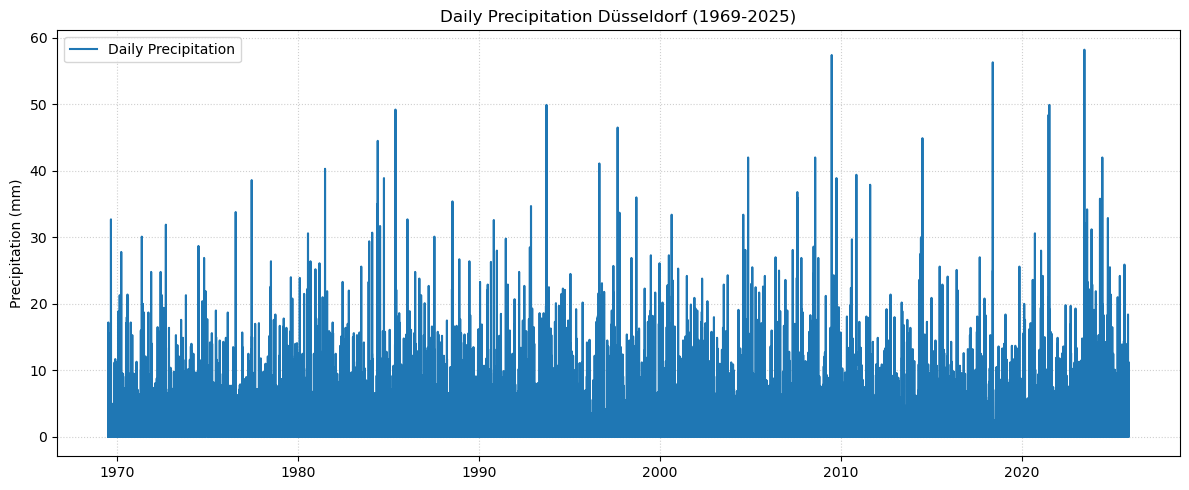

In [4]:
precipitation_file = 'data/dusseldorf_precipitation.csv'

df_precipitation = pd.read_csv(precipitation_file, sep=',', quoting=3, dtype=str, encoding='latin1', index_col=False)
df_precipitation.columns = df_precipitation.columns.str.replace('"', '').str.strip()
df_precipitation = df_precipitation.replace('"', '', regex=True)

date_col = 'Zeitstempel'
val_col = 'Wert'

df_precipitation[date_col] = pd.to_datetime(df_precipitation[date_col], format='%Y-%m-%d', errors='coerce')
df_precipitation[val_col] = pd.to_numeric(df_precipitation[val_col], errors='coerce')

df_precipitation = df_precipitation.dropna(subset=[date_col, val_col])
df_precipitation.set_index(date_col, inplace=True)
df_precipitation = df_precipitation[df_precipitation[val_col] >= 0]  
df_precipitation = df_precipitation.asfreq('D', fill_value=0.0)

# 5. Plotting
plt.figure(figsize=(12, 5))
plt.plot(df_precipitation.index, df_precipitation[val_col], label='Daily Precipitation')

plt.title(f'Daily Precipitation Düsseldorf ({df_precipitation.index.year.min()}-{df_precipitation.index.year.max()})')
plt.ylabel('Precipitation (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### Groundwater Level

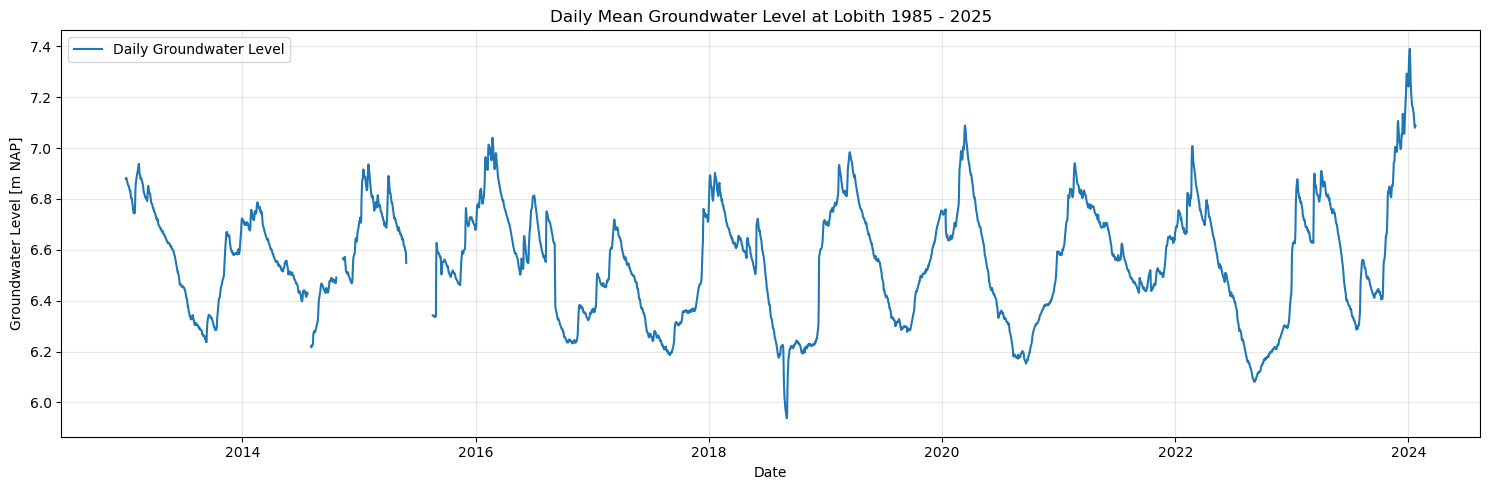

In [5]:
groundwater_file = 'data/groundwater.csv'

df_gw = pd.read_csv(groundwater_file, delimiter=';')
df_gw['meetwaarde (m NAP)'] = df_gw['meetwaarde (m NAP)'] / 100
df_gw['date'] = pd.to_datetime(df_gw['datum'] + ' ' + df_gw['tijd'], dayfirst=True)
df_gw = df_gw.set_index('date')
df_gw = df_gw.drop(columns=['datum', 'tijd'])
df_gw = df_gw.resample('D').mean()

plt.figure(figsize=(15, 5))
plt.plot(df_gw.index, df_gw['meetwaarde (m NAP)'], label = "Daily Groundwater Level")
plt.xlabel("Date")
plt.ylabel("Groundwater Level [m NAP]")
plt.title("Daily Mean Groundwater Level at Lobith 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

### Combine Datasets into One Single Dataframe

To effectively combine all datasets into one single dataframe, the overlapping datapoints have to be found. 

In [6]:
def get_clean_series(data, new_name):
    """
    Takes a DataFrame, Series, or List and returns a clean, named Series.
    Handles grouping duplicates automatically.
    """

    # Handle Duplicates (Group by Date)
    grouped = data.groupby(level=0).mean(numeric_only=True)
    
    # Extract Values
    if isinstance(grouped, pd.DataFrame):
        # Verify we have numeric columns left
        if grouped.shape[1] > 0:
            s = grouped.iloc[:, 0]
        else:
            # Fallback for empty or non-numeric frames
            return pd.Series(name=new_name, dtype='float64')
    else:
        s = grouped
        
    return s.rename(new_name)

s_discharge = get_clean_series(df_discharge, "Discharge_m3s")
s_temp      = get_clean_series(df_temperature, "Temperature_C")
s_precip    = get_clean_series(df_precipitation, "Precipitation_mm")
s_ground    = get_clean_series(df_gw, "Groundwater_m")

df_final = pd.concat([s_discharge, s_temp, s_precip, s_ground], axis=1)
df_final = df_final.sort_index()
df_final = df_final.dropna()

## NPBN Analysis

### DAG (Directed Acyclic Graph)

In [7]:
N = df_final.shape[1] 
parents1 = [None]*N  

parents1[0] = []   # Discharge has no parents       
parents1[1] = [0]  # Temperature is the parent of Discharge          
parents1[2] = [0]  # Precipitation is the parent of Discharge    
parents1[3] = [0]  # Groundwater is the parent of Discharge

### No time lag correlation analysis

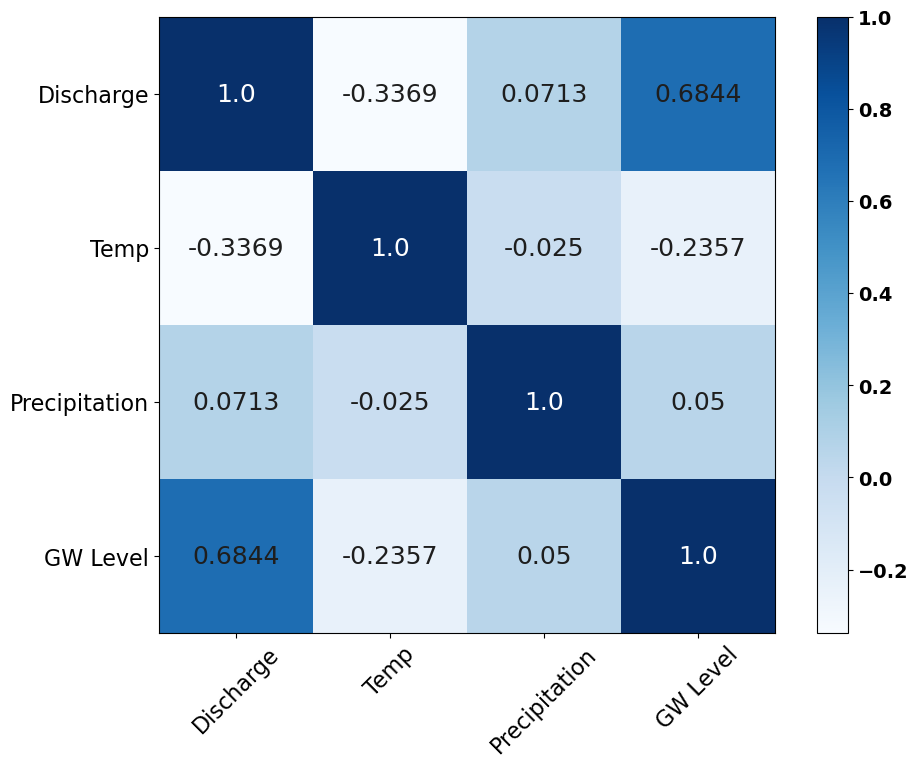

In [8]:
R_BN_1 = bn_rankcorr(parents1, df_final, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Time Lag correlation analysis

#### Optimal time lag calculation

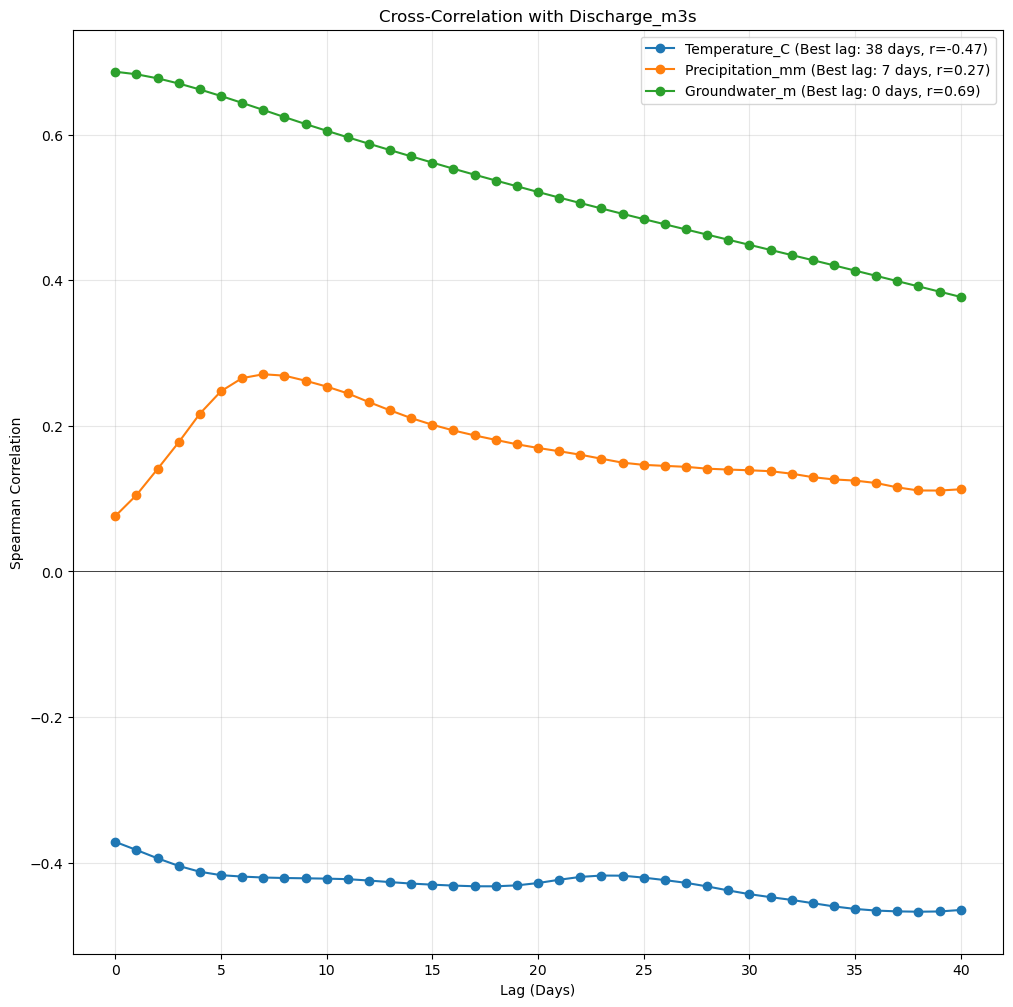

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [9]:
def analyze_lag(df, target, parent, max_lag=40):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        shifted_parent = df[parent].shift(lag)
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    abs_corrs = [abs(c) for c in correlations]
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = correlations[best_lag]
    
    return lags, correlations, best_lag, best_corr

target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

plt.figure(figsize=(12, 12))

best_lags = {}

for parent in parents:
    lags, corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    plt.plot(lags, corrs, marker='o', label=f'{parent} (Best lag: {best_k} days, r={max_r:.2f})')

plt.title(f'Cross-Correlation with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('Spearman Correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

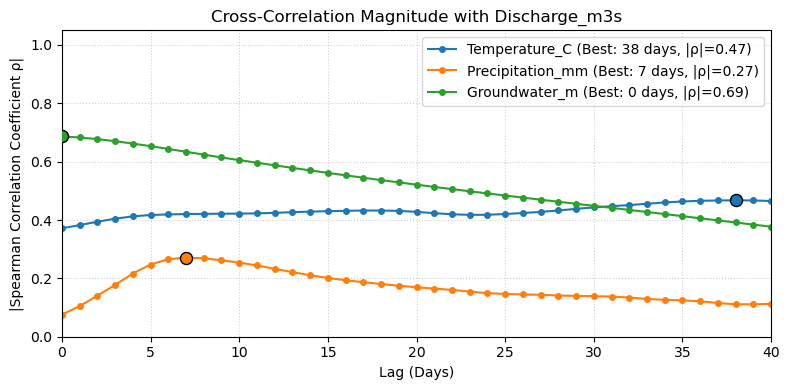

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Precipitation_mm: 7 days
 - Groundwater_m: 0 days


In [10]:
def analyze_lag(df, target, parent, max_lag=40):
    lags = range(max_lag + 1)
    correlations = []
    
    for lag in lags:
        # Shift parent data "down" by lag days
        shifted_parent = df[parent].shift(lag)
        
        # Calculate Spearman correlation
        corr = df[target].corr(shifted_parent, method='spearman')
        correlations.append(corr)
        
    # Take absolute values for analysis and plotting
    abs_corrs = [abs(c) for c in correlations]
    
    # Find best lag based on maximum ABSOLUTE correlation
    best_lag = abs_corrs.index(max(abs_corrs))
    best_corr = abs_corrs[best_lag] # This is now the absolute value
    
    return lags, abs_corrs, best_lag, best_corr

# Configuration
target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Precipitation_mm', 'Groundwater_m']

# Plotting - Changed figsize to be wider (better for time series/lags)
plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final, target_var, parent)
    best_lags[parent] = best_k
    
    # Plot the line
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    # Highlight the maximum point with a larger dot
    color = p[0].get_color() # Get the color of the line to match
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05) # Fixed y-axis for cleaner look
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

#### Calculate correlations with shifted timeseries

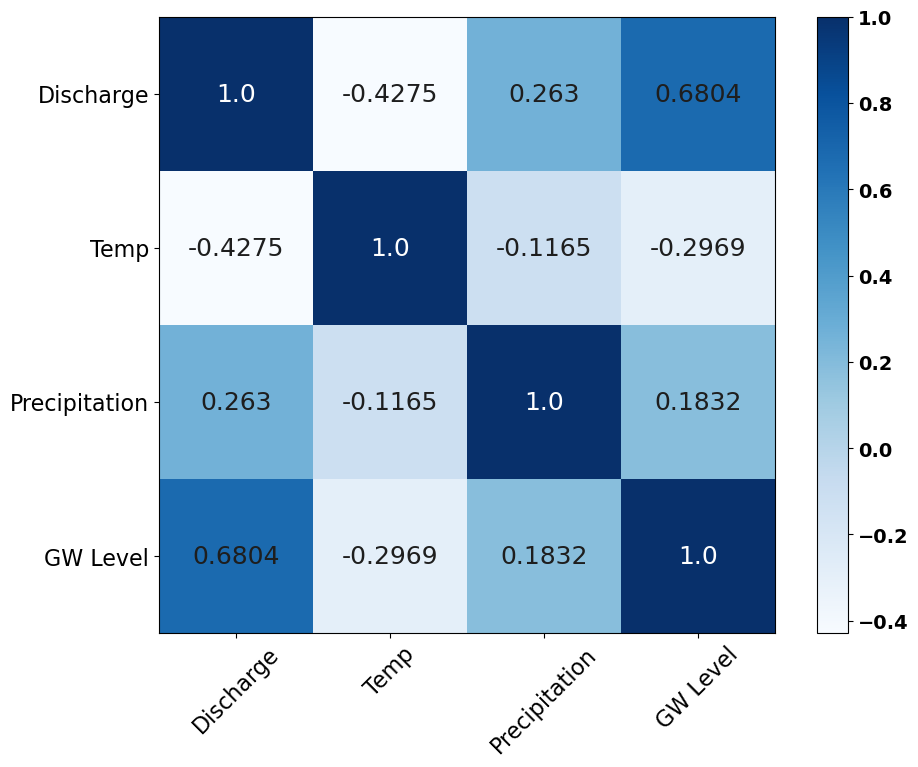

In [11]:
df_shifted = df_final.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted[col] = df_shifted[col].shift(lag)
    else:
        pass
        
df_shifted = df_shifted.dropna()

R_BN_1_shifted = bn_rankcorr(parents1, df_shifted, var_names=['Discharge', 'Temp', 'Precipitation', 'GW Level'], is_data=True, plot=True)

### Check if the use of NPBN is justified

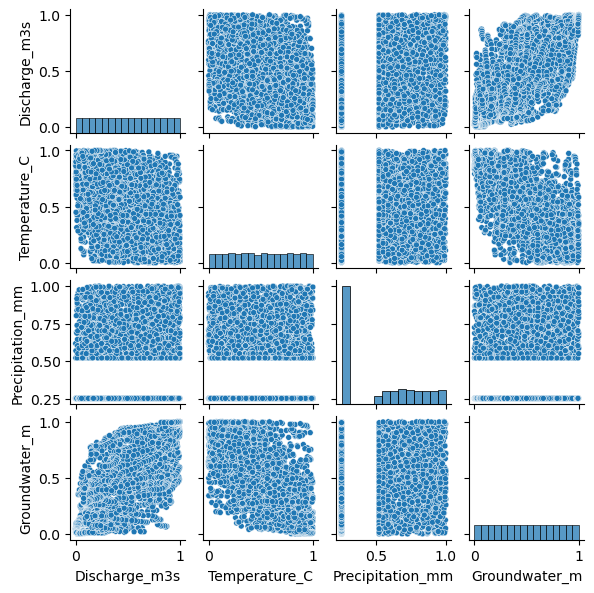

In [12]:
data = df_shifted

def unity(data):
    u_hat = stats.rankdata(data, method='average', axis=0)
    u_hat = u_hat / (data.shape[0] + 1)
    return pd.DataFrame(u_hat, columns=data.columns)

unity_data = unity(data)
sns.pairplot(unity_data, height=1.5,plot_kws=dict(size=.1))

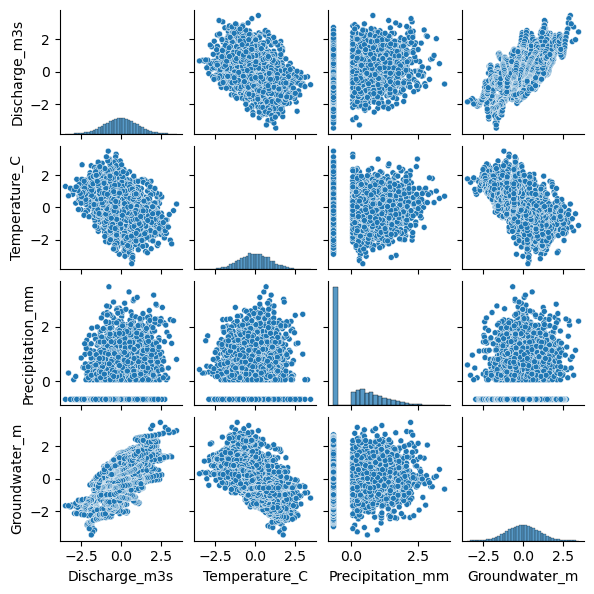

In [13]:
def sd_normal(data):
    u_hat = stats.rankdata(data, method='average', axis=0) / (len(data) + 1)
    sd_data = stats.norm.ppf(u_hat) # norm.ppf is the inverse of the CDF!!
    return sd_data

sd_data = pd.DataFrame(sd_normal(data), columns = data.columns)
sns.pairplot(sd_data, height=1.5,plot_kws=dict(size=.1))

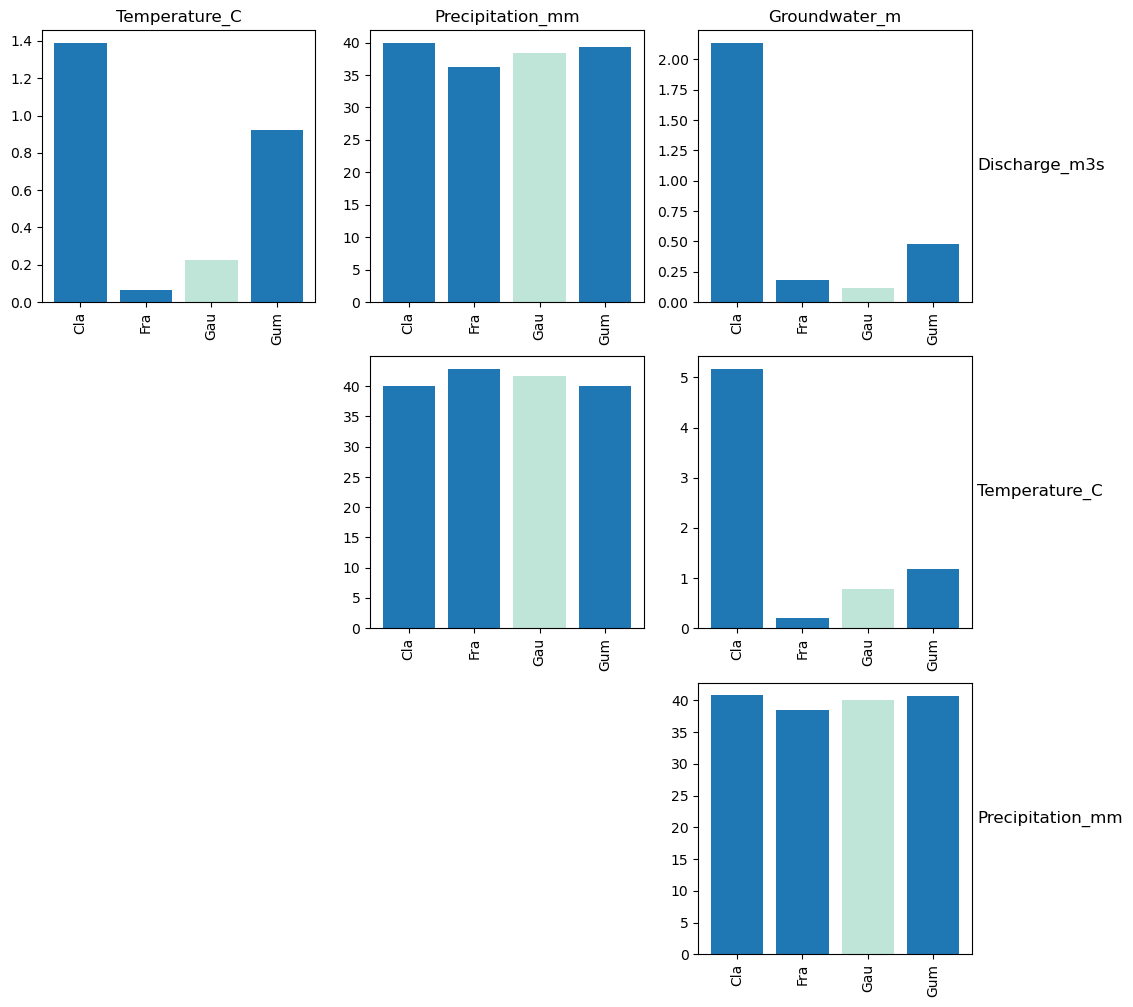

In [14]:
import warnings  
warnings.filterwarnings("ignore")

M = cvm_statistic(data, plot=1, names=data.columns,fig_name='CvM')

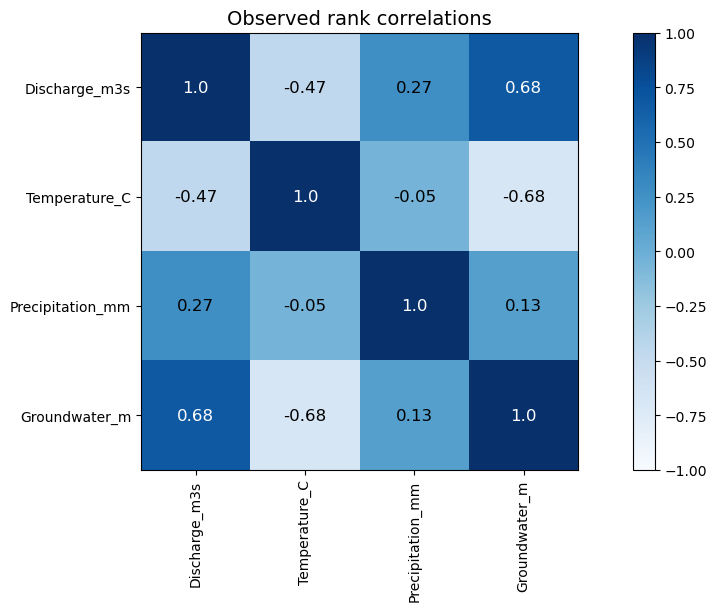

In [15]:
R_e = stats.spearmanr(data)[0]
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,1, figsize=(15,6), layout='constrained')
im1=axes.imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes.set_xticks(px, nam, rotation=90)
axes.set_yticks(px, nam)
axes.set_title('Observed rank correlations',fontsize=14)
zz2 = np.round(R_e, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes.text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=12, color=color)
cbar = fig.colorbar(im1,ax=axes, fraction=0.05, pad=0.04)

In [16]:
#Transform data to standard normal and store it in a DataFrame
standard_data = pd.DataFrame(sd_normal(data), columns=data.columns)

#Compute pearson correlation matrix
rho_N = np.corrcoef(standard_data, rowvar=False) # PEARSON!

#Transform to rank correlation matrix
R_N = 6 / np.pi * np.arcsin(rho_N / 2)

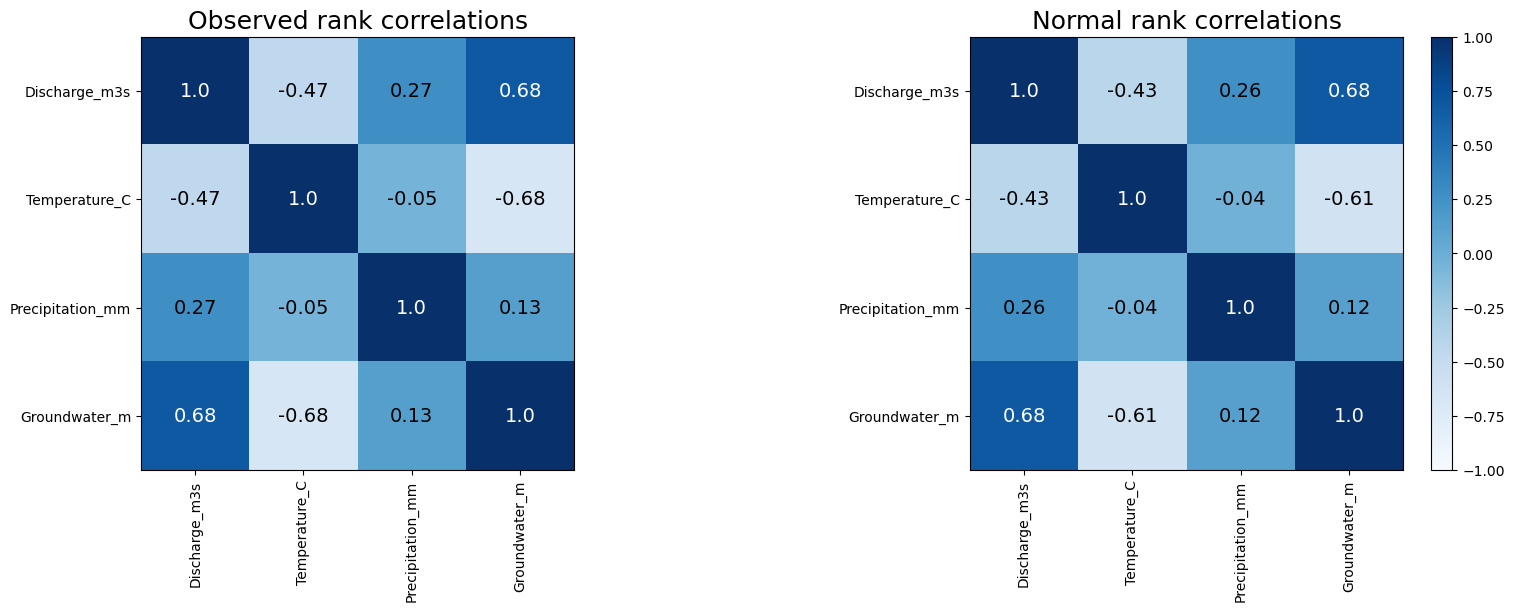

In [17]:
#Plot
nam = data.columns
px = list(range(len(nam)))

fig, axes = plt.subplots(1,2, figsize=(15,6), layout='constrained')
im1=axes[0].imshow(R_e, cmap='Blues', vmin=-1, vmax=1)
axes[0].set_xticks(px, nam, rotation=90)
axes[0].set_yticks(px, nam)
axes[0].set_title('Observed rank correlations',fontsize=18)
zz2 = np.round(R_e, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[0].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)

im1=axes[1].imshow(R_N, cmap='Blues', vmin=-1, vmax=1)
axes[1].set_xticks(px, nam, rotation=90)
axes[1].set_yticks(px, nam)
axes[1].set_title('Normal rank correlations',fontsize=18)
zz2 = np.round(R_N, 2)
zz = zz2.astype(str)
for i in range(len(nam)):
    for j in range(len(nam)):
        if zz2[i,j]>0.5:
            color = 'w'
        else:
            color = 'k'
        axes[1].text(j, i, zz[i, j],
                        ha="center", va="center",
                        fontsize=14, color=color)
        
cbar = fig.colorbar(im1,ax=axes[1], fraction=0.05, pad=0.04)

## Simulating Flood Events

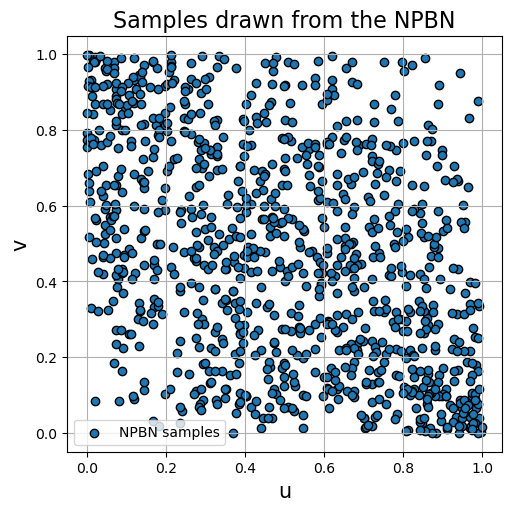

In [18]:
distributions_vars = ['uniform', 'uniform', 'uniform', 'uniform']
parameters_vars = [[0, 1], [0, 1], [0,1], [0,1]]

samples_BN = generate_samples(R=R_BN_1_shifted,
                              n=1000,
                              names=['Discharge', 'Temp', 'Precipitation', 'GW Level'],
                              data=[],
                              empirical_data=False,
                              distributions=distributions_vars,
                              parameters=parameters_vars)


fig, axes = plt.subplots(1,1, figsize=(5,5), layout='constrained')
axes.scatter(samples_BN.iloc[:, 0], samples_BN.iloc[:, 1], edgecolor='k', label ='NPBN samples')
axes.set_xlabel('u',fontsize=15)
axes.set_ylabel('v',fontsize=15)
axes.set_title('Samples drawn from the NPBN',fontsize=16)
axes.legend()
axes.grid()

## Rain with system memory (5 days)

In [19]:
df_precipitation_system_memory = df_precipitation.copy()
df_precipitation_system_memory['Wert'] = df_precipitation_system_memory['Wert'].rolling(window=5, min_periods=1).sum()
s_precip_system_memory    = get_clean_series(df_precipitation_system_memory, "Wert")
df_final_system_memory = pd.concat([s_discharge, s_temp, s_precip_system_memory, s_ground], axis=1)
df_final_system_memory = df_final_system_memory.sort_index()
df_final_system_memory = df_final_system_memory.dropna()

df_final_system_memory.head()

,Discharge_m3s,Temperature_C,Wert,Groundwater_m
2013-01-01,4191.446493,-5.8,13.0,6.879375
2013-01-02,3887.455644,-11.3,12.1,6.883000
2013-01-03,3536.374827,-7.4,10.9,6.881125
2013-01-04,3183.239792,-1.1,11.3,6.872875
2013-01-05,2874.311581,-2.8,9.0,6.868875


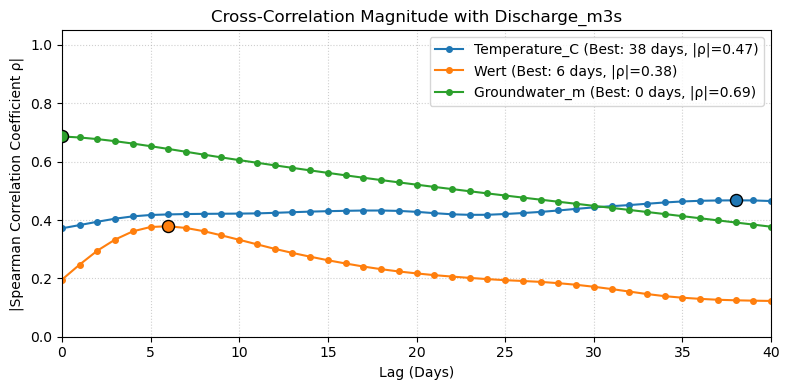

Optimal Shifts Found:
 - Temperature_C: 38 days
 - Wert: 6 days
 - Groundwater_m: 0 days


In [20]:

target_var = 'Discharge_m3s'
parents = ['Temperature_C', 'Wert', 'Groundwater_m'] 

plt.figure(figsize=(8, 4))

best_lags = {}

for parent in parents:
    if parent not in df_final_system_memory.columns:
        print(f"Warning: Column '{parent}' not found. Skipping.")
        continue
        
    lags, abs_corrs, best_k, max_r = analyze_lag(df_final_system_memory, target_var, parent)
    best_lags[parent] = best_k
    
    p = plt.plot(lags, abs_corrs, marker='o', markersize=4, 
                 label=f'{parent} (Best: {best_k} days, |ρ|={max_r:.2f})')
    
    color = p[0].get_color()
    plt.scatter(best_k, max_r, s=75, color=color, edgecolors='black', zorder=5)

plt.title(f'Cross-Correlation Magnitude with {target_var}')
plt.xlabel('Lag (Days)')
plt.ylabel('|Spearman Correlation Coefficient ρ|')
plt.xlim(0, 40)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("Optimal Shifts Found:")
for p, k in best_lags.items():
    print(f" - {p}: {k} days")

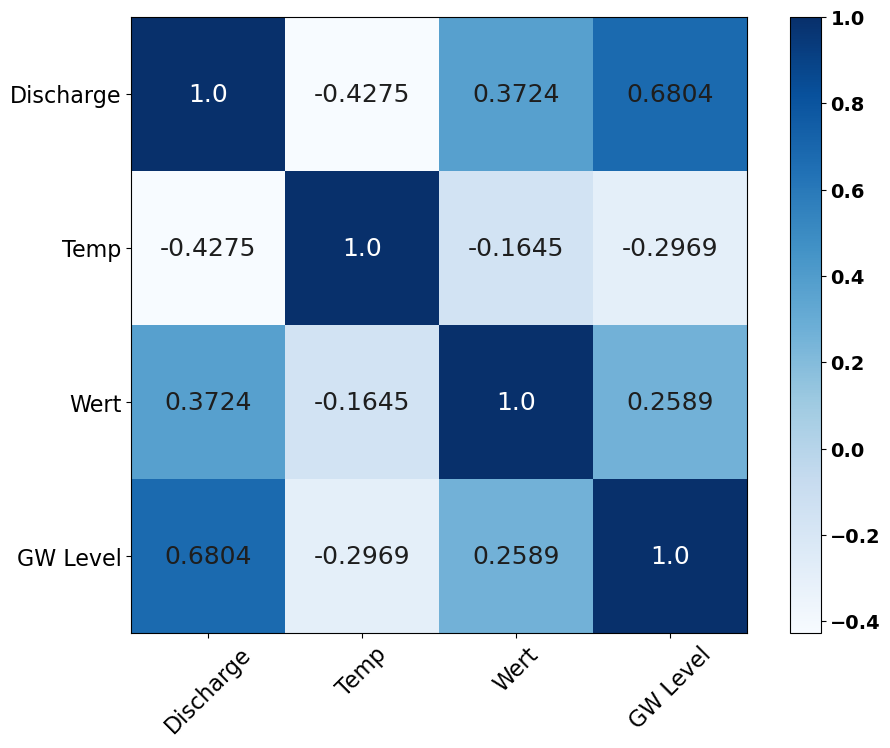

In [21]:
df_shifted_system_memory = df_final_system_memory.copy()

for col, lag in best_lags.items():
    if lag > 0:
        new_name = f"{col}_lag{lag}"
        df_shifted_system_memory[col] = df_shifted_system_memory[col].shift(lag)
    else:
        pass
        
df_shifted_system_memory = df_shifted_system_memory.dropna()
R_BN_1_shifted = bn_rankcorr(parents1, df_shifted_system_memory, var_names=['Discharge', 'Temp', 'Wert', 'GW Level'], is_data=True, plot=True)

## Snowmelt

Snowmelt data obtained from the ERA5 single levels dataset. taken every 3 hours and resampled to daily mean values. 

In [32]:
df_snowmelt = compile_era5_snowmelt('data/era5_snowmelt')

CSV not found. Processing raw NetCDF files in 'data/era5_snowmelt'...
Processed: era5_waves_1970.nc
Processed: era5_waves_1971.nc
Processed: era5_waves_1972.nc
Processed: era5_waves_1973.nc
Processed: era5_waves_1974.nc
Processed: era5_waves_1975.nc
Processed: era5_waves_1976.nc
Processed: era5_waves_1977.nc
Processed: era5_waves_1978.nc
Processed: era5_waves_1979.nc
Processed: era5_waves_1980.nc
Processed: era5_waves_1981.nc
Processed: era5_waves_1982.nc
Processed: era5_waves_1983.nc
Processed: era5_waves_1984.nc
Processed: era5_waves_1985.nc
Processed: era5_waves_1986.nc
Processed: era5_waves_1987.nc
Processed: era5_waves_1988.nc
Processed: era5_waves_1989.nc
Processed: era5_waves_1990.nc
Processed: era5_waves_1991.nc
Processed: era5_waves_1992.nc
Processed: era5_waves_1993.nc


,valid_time,latitude,longitude,smlt,number,expver,source_year
0,1970-01-01 00:00:00,46.6,9.40,0.0,0,0001,1970
1,1970-01-01 00:00:00,46.6,9.65,0.0,0,0001,1970
2,1970-01-01 03:00:00,46.6,9.40,0.0,0,0001,1970
3,1970-01-01 03:00:00,46.6,9.65,0.0,0,0001,1970
4,1970-01-01 06:00:00,46.6,9.40,0.0,0,0001,1970


,smlt
date,
1970-01-01,0.0
1970-01-02,0.0
1970-01-03,0.0
1970-01-04,0.0
1970-01-05,0.0


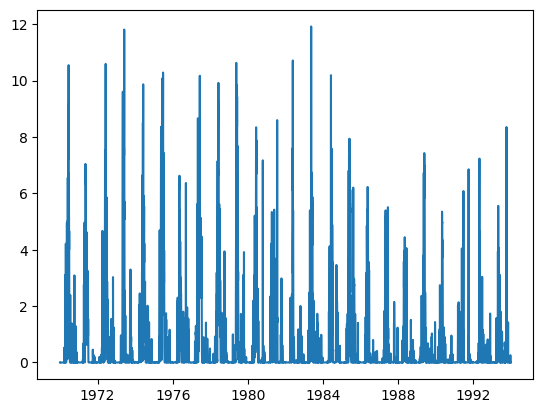

In [33]:
display(df_snowmelt.head())
df_snowmelt['valid_time'] = pd.to_datetime(df_snowmelt['valid_time'])
df_snowmelt = df_snowmelt.drop(columns=['number', 'expver', 'source_year'], errors='ignore')
df_snowmelt = df_snowmelt.groupby('valid_time')[['smlt']].mean()
df_snowmelt = df_snowmelt.resample('D').sum()
df_snowmelt.index.name = 'date'
df_snowmelt = df_snowmelt.sort_index()
df_snowmelt['smlt'] = df_snowmelt['smlt'] * 1000            # resample to mm instead of meters

s_snowmelt = get_clean_series(df_snowmelt, "Snowmelt")

display(df_snowmelt.head())

plt.plot(df_snowmelt.index, df_snowmelt['smlt'], label='Daily Snowmelt')


In [37]:
## Seasonality
df_final_seasonality = pd.concat([s_discharge, s_snowmelt, s_precip_system_memory, s_ground], axis=1)
df_final_seasonality = df_final_seasonality.sort_index()
df_final_seasonality = df_final_seasonality.dropna()

display(df_final_seasonality.head())



,Discharge_m3s,Snowmelt,Wert,Groundwater_m


Processing: All...
Processing: Winter...
Processing: Spring...
Processing: Summer...
Processing: Autumn...


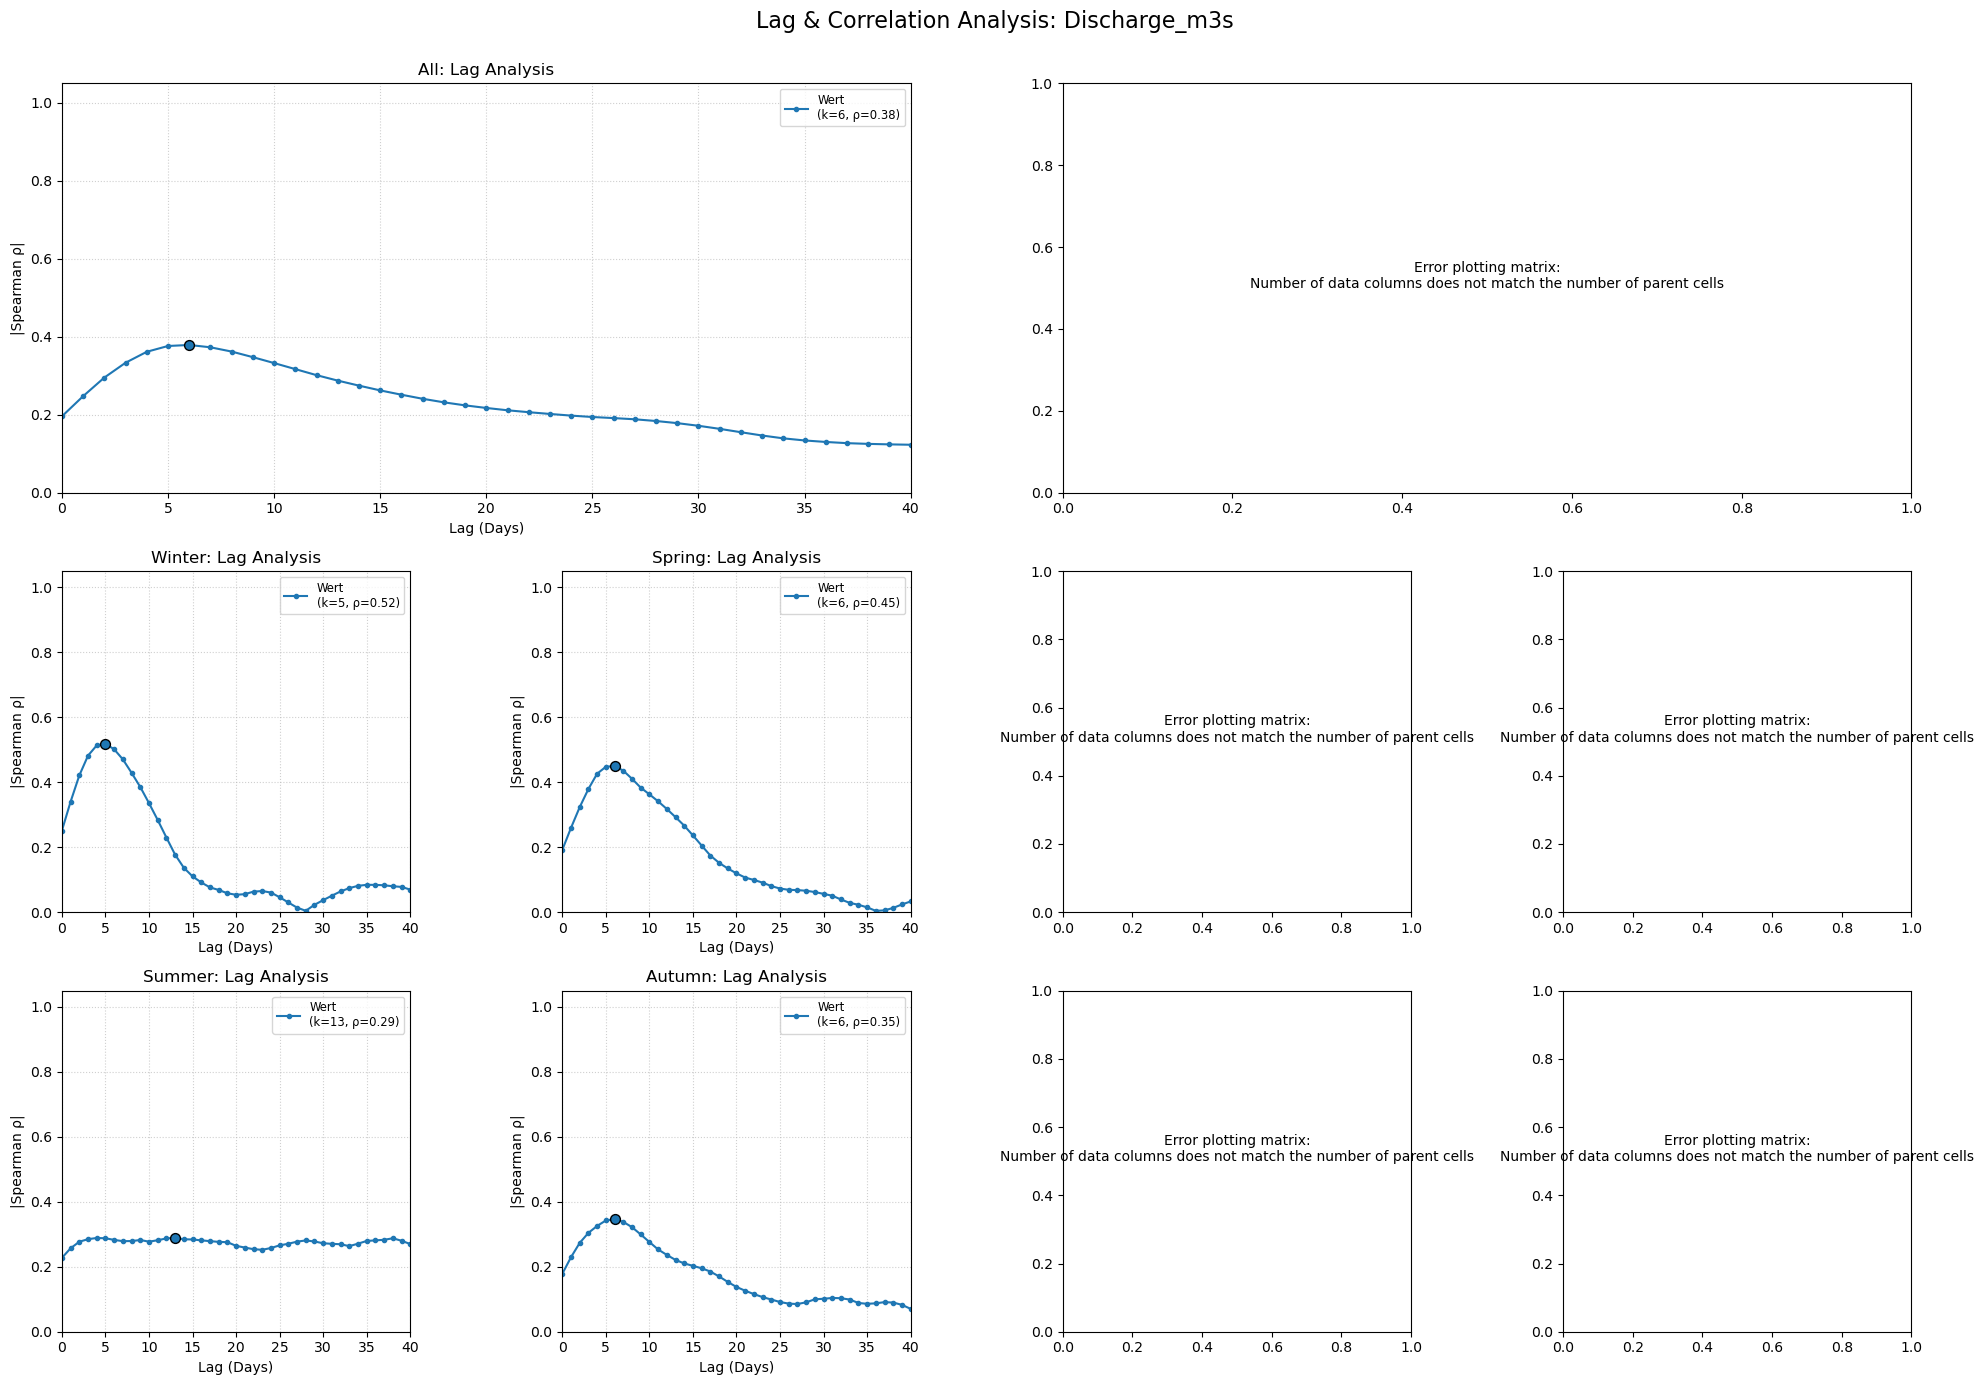

In [ ]:
target_var = 'Discharge_m3s'
parents = ['Snowmelt', 'Wert', 'Groundwater_m'] 


# --- Helper functions ---

if not isinstance(df_final_system_memory.index, pd.DatetimeIndex):
    df_final_system_memory.index = pd.to_datetime(df_final_system_memory.index)

def get_seasonal_data(df, season_name):
    if season_name == 'All':
        return df
    
    # Map months to seasons
    # Winter: 12, 1, 2 | Spring: 3, 4, 5 | Summer: 6, 7, 8 | Autumn: 9, 10, 11
    season_months = {
        'Winter': [12, 1, 2],
        'Spring': [3, 4, 5],
        'Summer': [6, 7, 8],
        'Autumn': [9, 10, 11]
    }
    
    mask = df.index.month.isin(season_months[season_name])
    return df.loc[mask]

# --- Plot Setup ---
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(3, 4, height_ratios=[1.2, 1, 1], width_ratios=[1, 1, 1, 1])
fig.suptitle(f"Lag & Correlation Analysis: {target_var}", fontsize=16, y=0.95)

# Define the order and locations for the loop
scenarios = ['All', 'Winter', 'Spring', 'Summer', 'Autumn']

# Mapping scenarios to GridSpec slices for (Lag Plot, Corr Plot)
# Format: [Lag_Grid_Slice, Corr_Grid_Slice]
layout_map = {
    'All':    [gs[0, 0:2], gs[0, 2:4]], # Top row, spanning 2 cols each
    'Winter': [gs[1, 0],   gs[1, 2]],   # Middle row, left side
    'Spring': [gs[1, 1],   gs[1, 3]],   # Middle row, right side
    'Summer': [gs[2, 0],   gs[2, 2]],   # Bottom row, left side
    'Autumn': [gs[2, 1],   gs[2, 3]]    # Bottom row, right side
}

# --- Main Loop ---
for season in scenarios:
    print(f"Processing: {season}...")
    
    # 1. Get Data Subset
    df_subset = get_seasonal_data(df_final_system_memory, season)
    
    if df_subset.empty:
        print(f"Warning: No data for {season}. Skipping.")
        continue

    # 2. Setup Axes
    ax_lag = fig.add_subplot(layout_map[season][0])
    ax_corr = fig.add_subplot(layout_map[season][1])

    # ---------------------------
    # A. Time Lag Analysis
    # ---------------------------
    best_lags = {}
    
    for parent in parents:
        if parent not in df_subset.columns:
            continue
            
        # Run your custom lag function
        lags, abs_corrs, best_k, max_r = analyze_lag(df_subset, target_var, parent)
        best_lags[parent] = best_k
        
        # Plotting
        p = ax_lag.plot(lags, abs_corrs, marker='o', markersize=3, 
                        label=f'{parent}\n(k={best_k}, ρ={max_r:.2f})')
        
        color = p[0].get_color()
        ax_lag.scatter(best_k, max_r, s=50, color=color, edgecolors='black', zorder=5)

    ax_lag.set_title(f'{season}: Lag Analysis')
    ax_lag.set_xlabel('Lag (Days)')
    ax_lag.set_ylabel('|Spearman ρ|')
    ax_lag.set_xlim(0, 40)
    ax_lag.set_ylim(0, 1.05)
    ax_lag.grid(True, linestyle=':', alpha=0.6)
    # Smaller legend for subplots to save space
    ax_lag.legend(fontsize='small', loc='best')

    # ---------------------------
    # B. Shift Data & Correlation Matrix
    # ---------------------------
    df_shifted = df_subset.copy()

    for col, lag in best_lags.items():
        if lag > 0:
            new_name = f"{col}_lag{lag}"
            df_shifted[col] = df_shifted[col].shift(lag)
    
    df_shifted = df_shifted.dropna()
    
    # Define variable names for the plot
    var_names_plot = ['Discharge', 'Snowmelt', 'Wert', 'GW Level']
    
    # Run your custom BN Rank Corr function
    # Note: passing the specific axis 'ax_corr' to your function is ideal. 
    # If bn_rankcorr doesn't accept an 'ax' argument, it will create a new figure 
    # and break this layout. Assuming we can pass ax or handle it.
    
    try:
        # Assuming bn_rankcorr can accept an 'ax' parameter. 
        # If your function strictly calls plt.figure(), you might need to modify it.
        # Here I simulate passing the axis if supported, or activating it.
        plt.sca(ax_corr) # Set current axis to the grid location
        
        # Modify the call below if your bn_rankcorr needs specific arguments
        bn_rankcorr(parents, df_shifted, var_names=var_names_plot, is_data=True, plot=True)
        
        ax_corr.set_title(f'{season}: Rank Correlation')
        
    except Exception as e:
        ax_corr.text(0.5, 0.5, f"Error plotting matrix:\n{e}", ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()